In [99]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve2d
from skimage.io import imread

In [100]:
rootfolder = '.'

Define the function to compute the kernel given the weights and the degree of the polynomial

In [101]:
def compute_2D_LPA_kernel(w, N):
    # compute the 2D LPA kernel for a given weights and polynomial degree
    # input:
    #   w: matrix containing the weights for the local LS problem
    #   N: degree of the polynomial approximation
    # return:
    #   g: the computed LPA kernel


    # window size is the lenght of the weight vector
    r, c = w.shape
    M = r*c

    # create the matrix T
    tx = np.linspace(0, 1, c)
    ty = np.linspace(0, 1, r)
    tx, ty = np.meshgrid(tx, ty)
    tx = tx.reshape(-1)
    ty = ty.reshape(-1)
    T = np.zeros((M,(N+1)**2))
    cnt = 0
    for i in range(N+1):
        for j in range(N-i+1):
            if i==0 and j==0:
                T[:, cnt] = np.ones(M)
            else:
                T[:, cnt] = tx**i * ty**j
            cnt = cnt + 1
    T = T[:, :cnt]

    # unroll the matrix of the weights
    w = w.reshape(-1)

    # generate the inverse of weights
    # set to zero weights that are inf
    winv = [0 if w[i] == 0 else 1/w[i] for i in range(len(w))]

    # define the weight matrix
    W = np.diag(w)
    Winv = np.diag(winv)

    ## construct the LPA kernel

    # comput the qr decomposition of WT
    Q, R = np.linalg.qr(W @ T, mode="reduced")

    # define Qtilde
    Qtilde = Winv @ Q

    # adjust Qtilde with the weights matrix squared
    W2Qtilde = W**2 @ Qtilde

    # select the central row of W2Qtilde
    row = W2Qtilde[(M-1)//2,:]

    # compute the kernel
    g_bar = Qtilde @ row

    #reshape the kernel in a matrix
    g_bar = g_bar.reshape(r,c)

    # flipping, since it is used in convolution
    g = g_bar[::-1, ::-1] 


    return g


Load the image and add the noise

In [102]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255

sigma_noise = 20/255
noisy_img = img + np.random.normal(size=img.shape) * sigma_noise

psnr_noisy = 10*np.log10(1/np.mean((img - noisy_img)**2))


Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

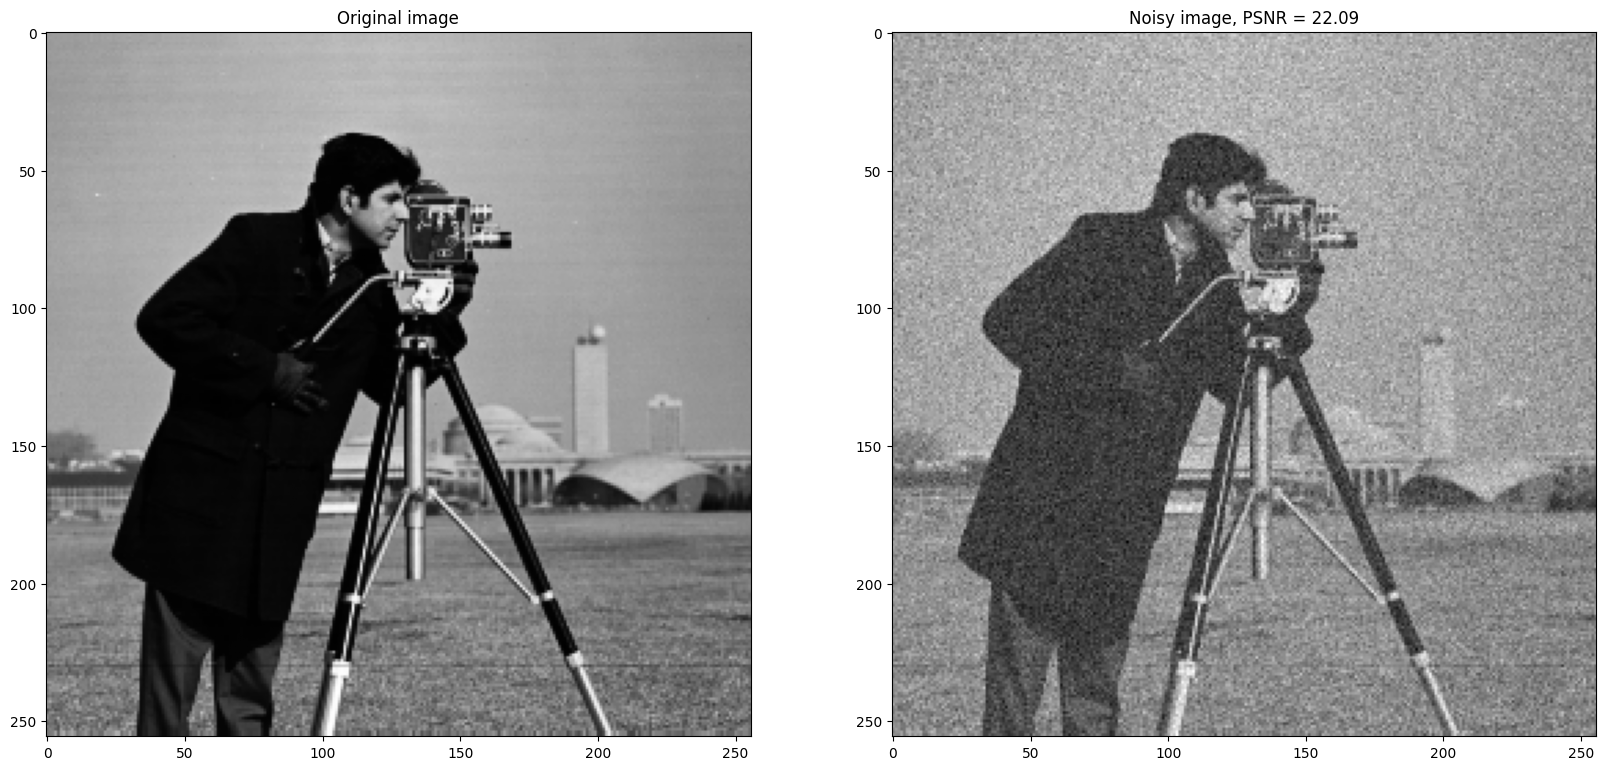

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

LPA-ICI 2D
----------
Set the LPA-ICI parameters

In [104]:
# maximum degree of polynomial used for fitting
N = 1

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# Set all the scale values
hmax = 21
all_h = np.arange(1, hmax+1)

Generate the LPA kernels for all the scales. Use centered weights.


In [105]:
all_g = []
for i, h in enumerate(all_h):
        # define the weights for the scale h symmetric

        # size of the weight MATRIX
        w = np.ones((2* h+1, 2*h+1))
        
        # compute and store the kernel g
        g = compute_2D_LPA_kernel(w, N)
        all_g.append(g)

Initialize all the variables for the ICI rule

In [106]:
# initialize the estimate for each scale
yhat = np.zeros((img.shape))

# initialize the vector containing the best scale for each sample
best_scale = np.zeros(shape=yhat.shape)

# initialize the lower and upper bound matrices
lower_bounds = - np.inf * np.ones(shape=yhat.shape)
upper_bounds = np.inf * np.ones(shape=yhat.shape)

Loop over all the scales

In [107]:
from scipy.signal import convolve2d

for i, h in enumerate(all_h):
    g = all_g[i]

    # compute the estimate for the scale h
    yhat_h = convolve2d(noisy_img, g, mode="same", boundary="symm")

    # compute the lower and upper bound of the confidence interval for the scale h
    norm_g = np.sqrt(sigma_noise**2 * np.linalg.norm(g)**2)
    lb = yhat_h - Gamma * norm_g
    ub = yhat_h + Gamma * norm_g

    # update the lower and upper bounds
    lower_bounds = np.maximum(lower_bounds, lb)
    upper_bounds = np.minimum(upper_bounds, ub)

    # identify for which pixels h is the best scale according to the
    # ICI rule and update best_scale accordingly
    mask = (upper_bounds < lower_bounds) & (best_scale == 0)
    if i > 0:
        best_scale[mask] = all_h[i-1]
        yhat[mask] = convolve2d(noisy_img, all_g[i-1], mode="same", boundary="symm")[mask]

# fallback: pixels where ICI never triggered get the largest scale
mask = (best_scale == 0)
best_scale[mask] = all_h[-1]
yhat[mask] = convolve2d(noisy_img, all_g[-1], mode="same", boundary="symm")[mask]

Compute the PSNR

In [108]:
psnr = 10*np.log10(1/np.mean((img-yhat)**2))

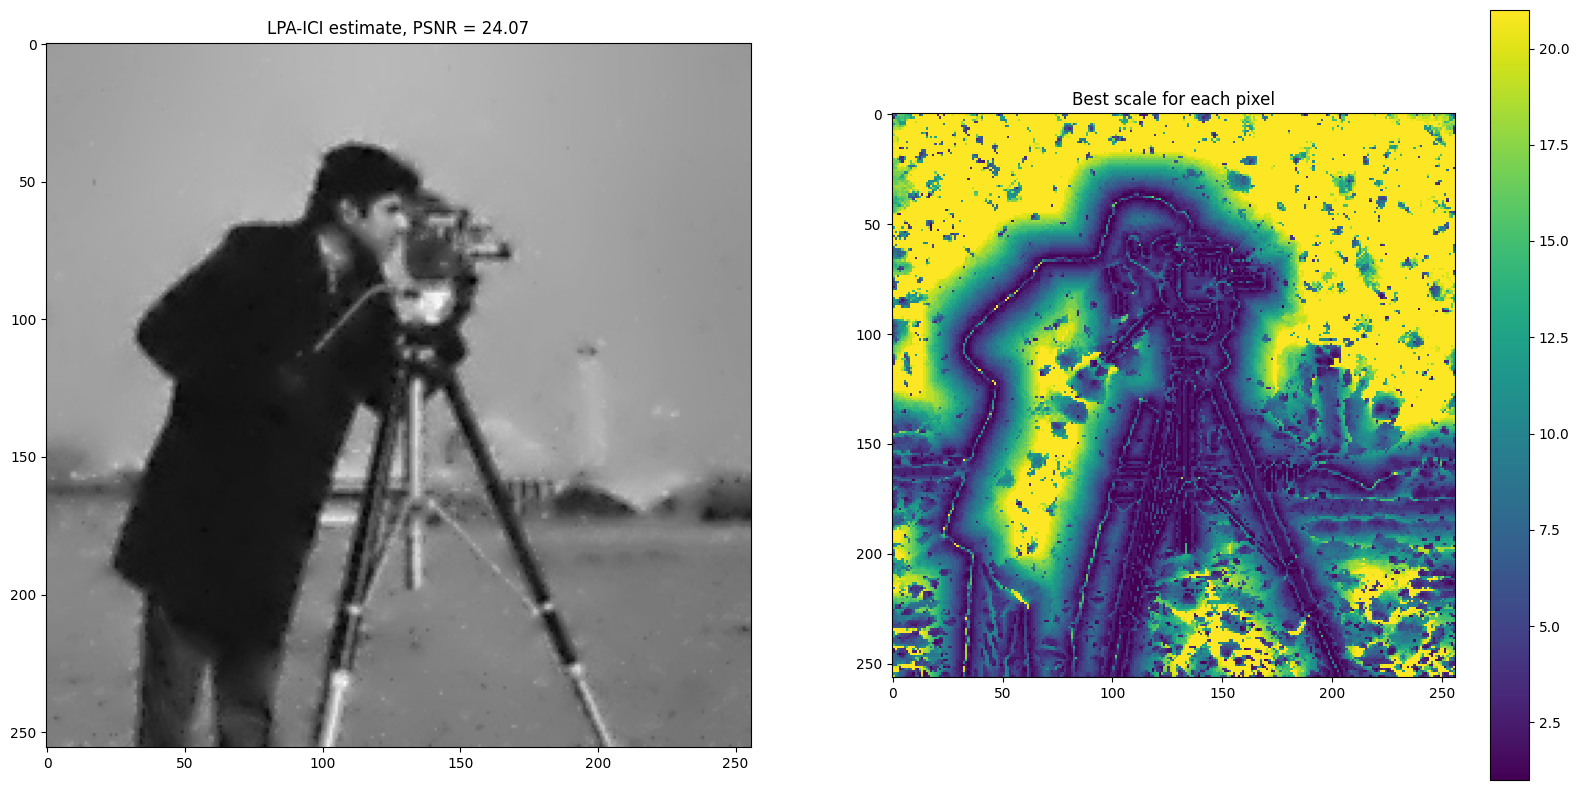

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(yhat, cmap='gray')
ax[0].set_title(f'LPA-ICI estimate, PSNR = {psnr:.2f}')

ax[1].imshow(best_scale)
ax[1].set_title('Best scale for each pixel')
fig.colorbar(ax[1].pcolormesh(best_scale), ax=ax[1])

Anisotropic LPA-ICI
------------------------
Set the parameters


In [110]:
# maximum degree of polynomial used for fitting
N = 1

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# Set all the scale values
hmax = 21
all_h = np.arange(1, hmax+1)

# set all the direction values
all_theta = np.arange(4)

Generate the LPA kernels for all the scales and all the directions

In [111]:
all_g = []

for theta in all_theta:

    all_g_theta = []
    for i, h in enumerate(all_h):
        w = np.zeros((2*h+1, 2*h+1))
        # define the weights for the scale h and the direction theta
        if theta == 0:
            w[0:h+1, 0:h+1] = 1  # top left
        elif theta == 1:
            w[0:h+1, h+1-1:] = 1  # topright
        elif theta == 2:
            w[h+1-1:, 0:h+1] = 1  # bottomleft
        elif theta == 3:
            w[h+1-1:, h+1-1:] = 1  # bottom right

        # compute and store the kernel g
        print(w)
        g = compute_2D_LPA_kernel(w, N)

        all_g_theta.append(g)

    all_g.append(all_g_theta)


[[1. 1. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
[[1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 

Initialize all the variables

In [112]:
# initialize the estimate for each scale
yhat = np.zeros(img.shape)

# initialize the matrix of the aggregation weights
weights = np.zeros(img.shape)


Use the LPA-ICI to compute find the best scale for each direction and compute the finale estimates

In [113]:
for theta in all_theta:
    yhat_theta = np.zeros(img.shape)
    var_theta = np.zeros(img.shape)
    lower_bounds = -np.inf * np.ones(shape=img.shape)
    upper_bounds = np.inf * np.ones(shape=img.shape)
    best_scale = np.zeros(img.shape)  
    
    all_g_theta = all_g[theta]
    for i, h in enumerate(all_h):
        g = all_g_theta[i]

        yhat_h = convolve2d(noisy_img, g, mode="same", boundary="symm")

        norm_g = np.sqrt(sigma_noise**2 * np.linalg.norm(g)**2)
        lb = yhat_h - Gamma * norm_g
        ub = yhat_h + Gamma * norm_g

        lower_bounds = np.maximum(lower_bounds, lb)
        upper_bounds = np.minimum(upper_bounds, ub)

        mask = (upper_bounds < lower_bounds) & (best_scale == 0)
        if i > 0:
            best_scale[mask] = all_h[i-1]
            yhat_theta[mask] = convolve2d(noisy_img, all_g_theta[i-1], mode="same", boundary="symm")[mask]  # BUG FIX 2
            var_theta[mask] = sigma_noise**2 * np.linalg.norm(all_g_theta[i-1])**2  

    mask = (best_scale == 0)
    best_scale[mask] = all_h[-1]
    yhat_theta[mask] = convolve2d(noisy_img, all_g_theta[-1], mode="same", boundary="symm")[mask]
    var_theta[mask] = sigma_noise**2 * np.linalg.norm(all_g_theta[-1])**2  

    yhat += yhat_theta / var_theta
    weights += 1 / var_theta

yhat = yhat / weights

Compute the PSNR

In [114]:
psnr = 10*np.log10(1/np.mean((img-yhat)**2))

Text(0.5, 1.0, 'LPA-ICI estimate, PSNR = 27.14')

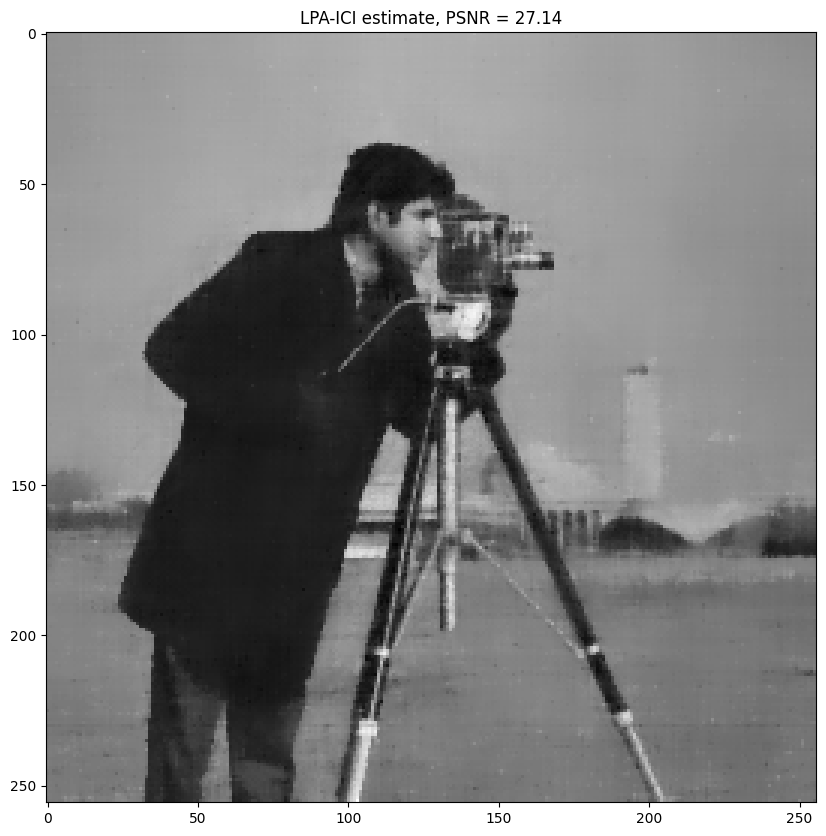

In [115]:
plt.figure(figsize=(10,10))
plt.imshow(yhat, cmap='gray')
plt.title(f'LPA-ICI estimate, PSNR = {psnr:.2f}')
